In [1]:
%matplotlib inline

import os

import pandas as pd

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

import scipy.stats as st
from scipy.optimize import minimize

#### Shen, Hopkins luminosity function

In [2]:
import sys
sys.path.append("/Users/colinburke/research/quasarlf/pubtools")
os.chdir("/Users/colinburke/research/quasarlf/pubtools")

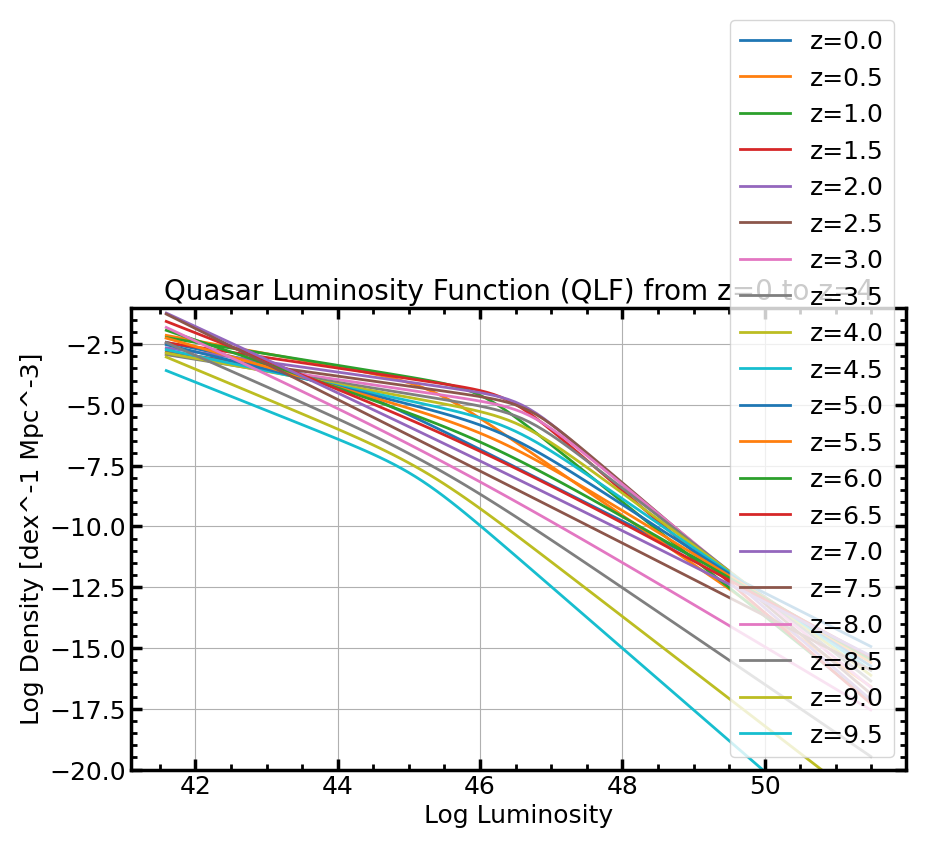

In [26]:
from utilities import return_bolometric_qlf

# Assuming the function to get the quasar LF is named `get_quasar_lf` in the utilities.py file

# Generate redshift values from 0 to 4
redshifts = np.linspace(0, 10, 200)

# Compute QLF for each redshift
qlf_values = [return_bolometric_qlf(redshift=z) for z in redshifts]

# Extract luminosity and density values
luminosities = qlf_values[0][0]  # Assuming luminosities are the same for all redshifts
Mi = 90 - 2.5*luminosities #TODO: K-correction

# Extract densities for each redshift
densities = np.array([qlf[1] for qlf in qlf_values])


# Plot the QLF
plt.figure(figsize=(10, 6))
for i, z in enumerate(redshifts[::10]):  # Plot every 10th redshift for clarity
    plt.plot(luminosities, densities[i * 10], label=f'z={z:.1f}')
    #plt.plot(apparent_magnitudes, densities[i * 10], label=f'z={z:.1f} (apparent)')
plt.xlabel('Log Luminosity')
plt.ylabel('Log Density [dex^-1 Mpc^-3]')
plt.title('Quasar Luminosity Function (QLF) from z=0 to z=4')
plt.ylim(-20, -1)
plt.legend()
plt.grid()
plt.show()


#### Apparent magnitude distribution

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_53407/3476625595.py:28: RuntimeWarning: divide by zero encountered in log10
  apparent_magnitudes_bin = Mi + 5 * np.log10(cosmo.luminosity_distance(z).to(u.pc).value / 10)
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_53407/3476625595.py:29: RuntimeWarning: divide by zero encountered in log10
  sampled_m = sampled_Mi + 5 * np.log10(cosmo.luminosity_distance(z).to(u.pc).value / 10)


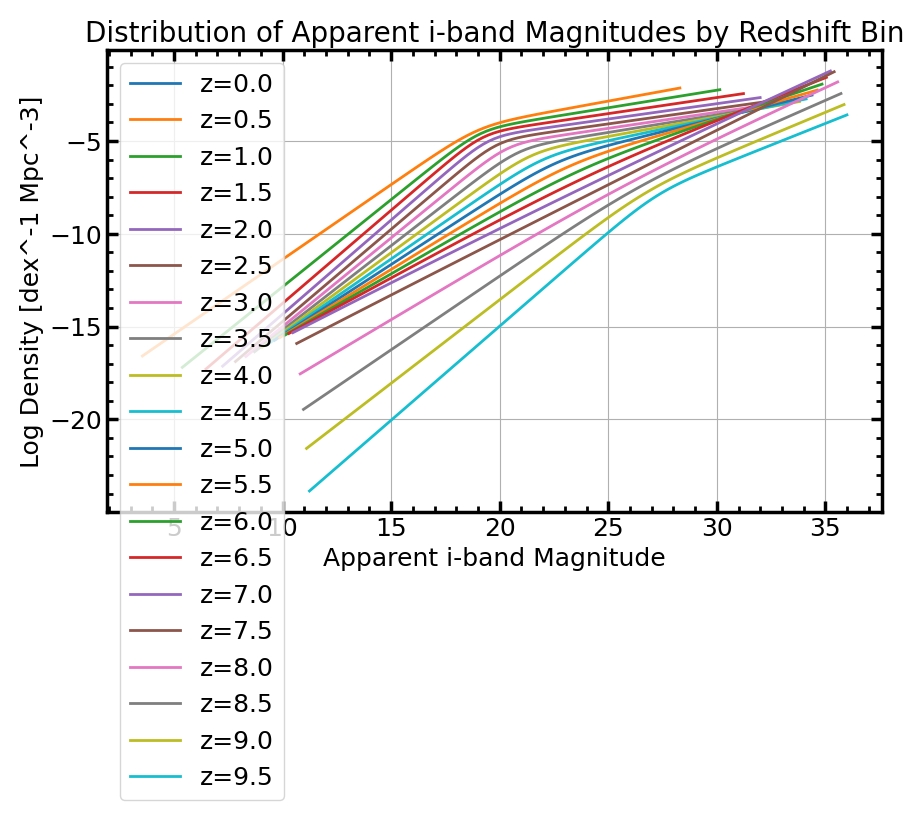

In [55]:
from scipy.interpolate import interp1d

alpha_nu = -0.5

# Compute apparent i-band magnitudes for each redshift bin
apparent_magnitude_distributions = []
sampled_apparent_magnitudes = []

for i, z in enumerate(redshifts):

    # Compute the cumulative distribution function (CDF)
    cdf = np.cumsum(10**densities[i,:])
    cdf /= cdf[-1]  # Normalize to make it a proper CDF

    # Create an interpolation function for the inverse CDF
    inverse_cdf = interp1d(cdf, luminosities, bounds_error=False, fill_value="extrapolate")

    # Generate random samples from a uniform distribution
    random_samples = np.random.uniform(0, 1, size=100000)

    # Map the random samples through the inverse CDF to get samples
    sampled_luminosities = inverse_cdf(random_samples)

    # Convert sampled luminosities to absolute magnitudes Mi
    sampled_Mi = 90 - 2.5 * sampled_luminosities

    # Compute apparent magnitudes for the luminosity function at this redshift
    apparent_magnitudes_bin = Mi + 5 * np.log10(cosmo.luminosity_distance(z).to(u.pc).value / 10)
    sampled_m = sampled_Mi + 5 * np.log10(cosmo.luminosity_distance(z).to(u.pc).value / 10)
    # Apply a simple K-correction (example: K(z) = -2.5 * log10(1+z))
    K_corr = -2.5 * (1 + alpha_nu) * np.log10(1 + z)
    sampled_m_obs = sampled_m + K_corr

    mask = sampled_m_obs < 25
    sampled_m_obs = sampled_m_obs[mask]

    apparent_magnitude_distributions.append((apparent_magnitudes_bin, densities[i]))
    sampled_apparent_magnitudes.append(sampled_m_obs)

# Plot the distribution of apparent i-band magnitudes for each redshift bin
plt.figure(figsize=(10, 6))
for i, z in enumerate(redshifts[::10]):  # Plot every 10th redshift for clarity
    apparent_magnitudes_bin, density_bin = apparent_magnitude_distributions[i * 10]
    plt.plot(apparent_magnitudes_bin, density_bin, label=f'z={z:.1f}');

plt.xlabel('Apparent i-band Magnitude')
plt.ylabel('Log Density [dex^-1 Mpc^-3]')
plt.title('Distribution of Apparent i-band Magnitudes by Redshift Bin')
plt.legend()
plt.grid()
plt.show()

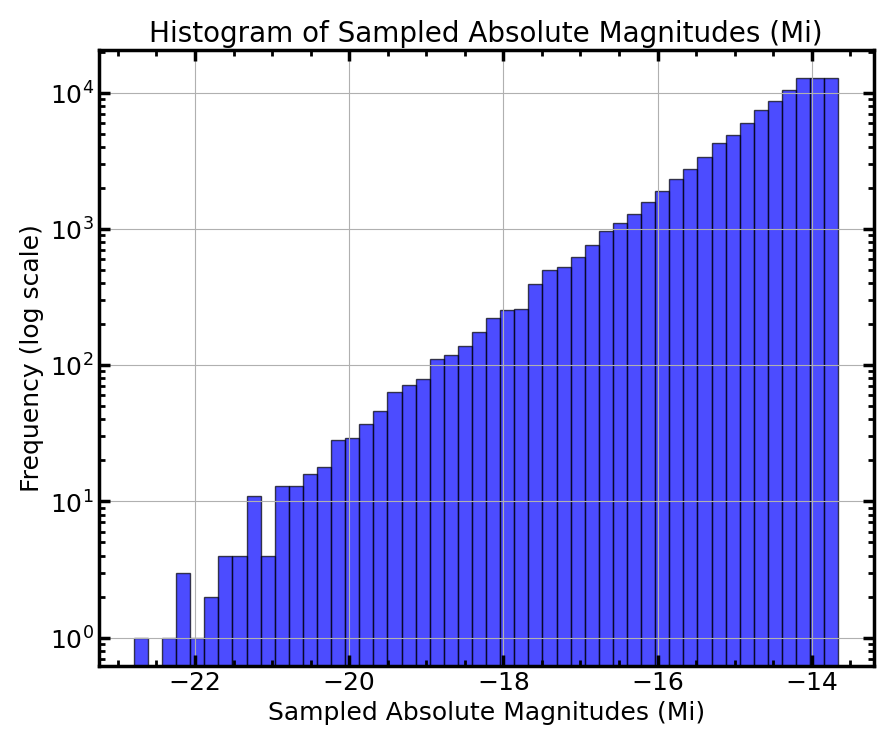

In [56]:
plt.hist(sampled_Mi, bins=50, log=True, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Sampled Absolute Magnitudes (Mi)')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Sampled Absolute Magnitudes (Mi)')
plt.grid(True)
plt.show()

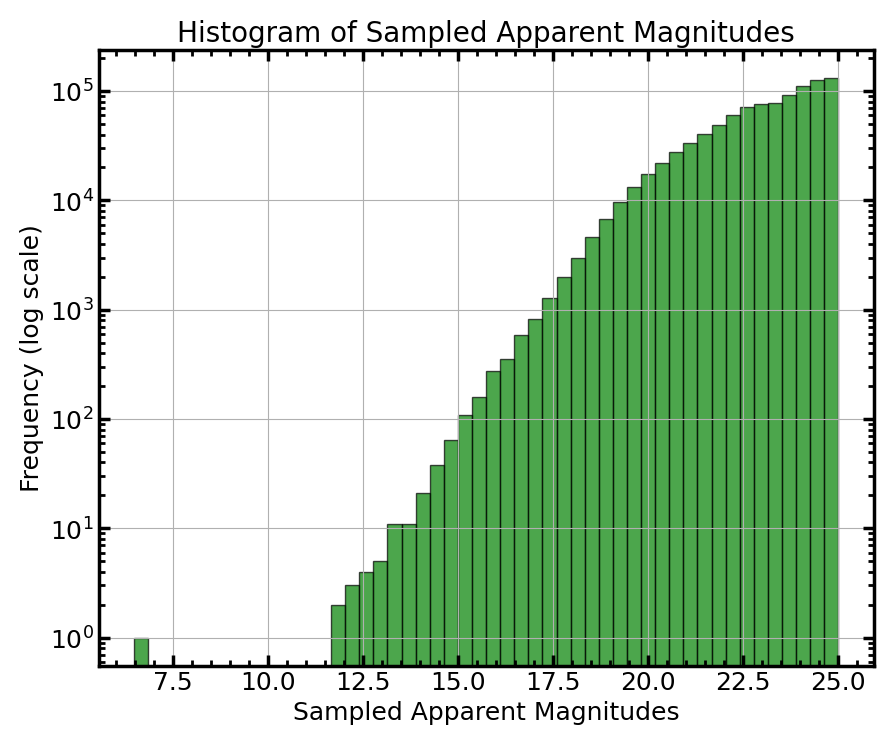

In [57]:
# Flatten the list of sampled_apparent_magnitudes into a single array
flattened_sampled_apparent_magnitudes = np.concatenate(sampled_apparent_magnitudes)
flattened_sampled_apparent_magnitudes = flattened_sampled_apparent_magnitudes[np.isfinite(flattened_sampled_apparent_magnitudes)]

# Plot the histogram
plt.hist(flattened_sampled_apparent_magnitudes, bins=50, log=True, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Sampled Apparent Magnitudes')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Sampled Apparent Magnitudes')
plt.grid(True)
plt.show()

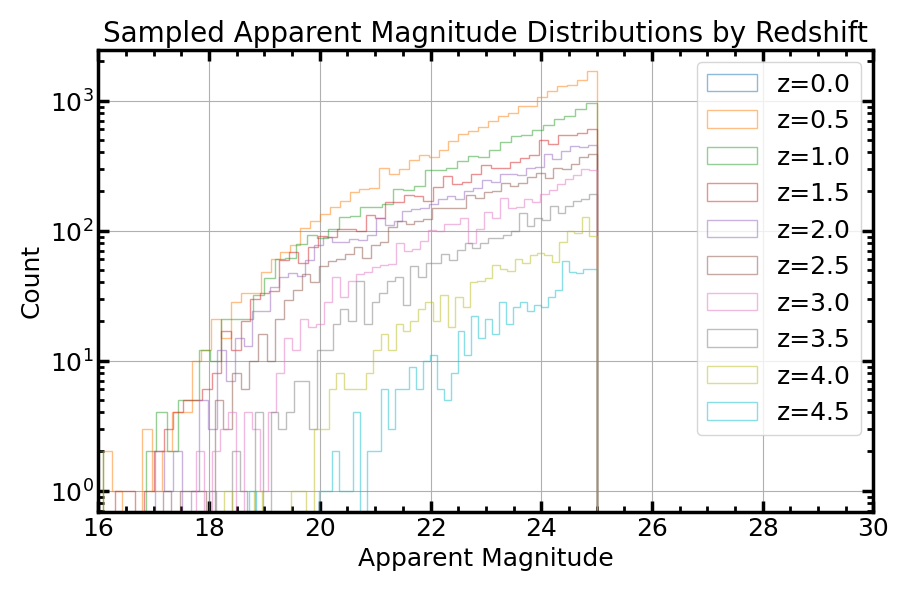

In [58]:
plt.figure(figsize=(10, 6))
for idx, (z_val, mags) in enumerate(zip(redshifts, sampled_apparent_magnitudes)):
    if z_val > 5:
        break
    if idx % 10 == 0:  # Plot every 10th redshift for clarity
        plt.hist(mags[np.isfinite(mags)], bins=50, alpha=0.5, label=f'z={z_val:.1f}', histtype='step')
plt.xlabel('Apparent Magnitude')
plt.ylabel('Count')
plt.semilogy()
plt.xlim(16, 30)
plt.title('Sampled Apparent Magnitude Distributions by Redshift')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
import h5py

# Save the sampled apparent magnitudes and corresponding redshift bin to an HDF5 file
with h5py.File('/Users/colinburke/research/isaque/eztaox/tutorials/sampled_apparent_magnitudes_redshift.h5', 'w') as h5file:
    h5file.create_dataset('sampled_apparent_magnitudes', data=sampled_apparent_magnitudes[i])
    h5file.create_dataset('redshift_bin', data=[redshifts[i]])

In [20]:
import h5py

# Stack the sampled_apparent_magnitudes into a single array
stacked_sampled_apparent_magnitudes = np.concatenate(sampled_apparent_magnitudes)

# Save the stacked array to an HDF5 file
with h5py.File('/Users/colinburke/research/isaque/eztaox/tutorials/stacked_sampled_apparent_magnitudes.h5', 'w') as h5file:
    h5file.create_dataset('stacked_apparent_magnitudes', data=stacked_sampled_apparent_magnitudes)

#### Redshift integrated LF